# O2 Selective Opacity Exclusion Analysis

Compares six cases for the O2-rich Mini-Neptune (Case 2 parameters) where individual O2 opacity types are selectively excluded:
- **line** only (removes O2 band absorption, e.g. A-band at 760 nm)
- **continuum** only (removes O2 CIA)
- **rayleigh** only (removes O2 Rayleigh scattering)
- **continuum + rayleigh**
- **continuum + line**
- **line + rayleigh**

Reference: standard O2-rich case (`RLS_O2Rich_MiniNep_cld0.5.pkl`, all opacity included).

Parameters: rad=2, Z=3.125x, Tint=200K, a=1 AU, C/O=0.01x solar, Kzz=5, cloud_frac=0.5

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()  # assumes notebook is run from the project root
sys.path.insert(0, str(_root / 'MiniNepGrid_Scripts'))
sys.path.insert(0, str(_root / 'ReflectedSpectra_Scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
from cycler import cycler
from matplotlib.patches import Patch

In [2]:
# Color palettes
WONG_MiniNep_Gas = [
        "#0072B2",
        "#CC79A7",
        "#777777",
        "#009E73",
        "#000000"]

# 6-color palette for the 6 exclusion cases (ref = black)
WONG6 = [
        "#0072B2",   # line only
        "#CC79A7",   # continuum only
        "#009E73",   # rayleigh only
        "#D55E00",   # continuum + rayleigh
        "#E69F00",   # continuum + line
        "#56B4E9",   # line + rayleigh
        "#000000"]   # reference (standard)

WONG = ["#000000", "#0072B2", "#CC79A7", "#777777", "#009E73", "#56B4E9", "#D55E00", "#E69F00"]


def plot_reflected_spectrum_final(
    wno=None,
    alb=None,
    inputs=None,
    legend_label=None,
    ax1=None,
    solid_indices=None,
    dashed_indices=None,
    fill_indices=None,
    fill_between_ref=False,
    fill_ref_index=None,
    use_patch_legend=True,
    show_legend=True,
    show_xlabel=False,
    colors=None,
):
    if colors is None:
        colors = WONG

    n = len(wno)
    solid_indices = set(solid_indices or [])
    dashed_indices = set(dashed_indices or [])
    fill_indices = set(fill_indices or [])

    standalone = ax1 is None
    if standalone:
        fig, ax1 = plt.subplots(1, 1, figsize=(7.25, 2.5))

    ax1.set_prop_cycle(cycler(color=colors))
    fill_ref_index = fill_ref_index if fill_ref_index is not None else 0
    legend_handles = []
    seen = set()

    for i in range(n):
        if inputs is not None and inputs[i] is not None:
            print("_".join(map(str, inputs[i])))

        wl = 1e4 / np.array(wno[i])
        color = colors[i % len(colors)]

        if i in solid_indices:
            linestyle = '-'; lw = 2.0
        elif i in dashed_indices:
            linestyle = '--'; lw = 1.0
        else:
            linestyle = '-'; lw = 2.0

        label = legend_label[i] if show_legend else None

        ax1.plot(wl, alb[i], linestyle=linestyle, lw=lw, color=color, label=label)

        if i in fill_indices:
            if fill_between_ref:
                ax1.fill_between(
                    wl,
                    np.array(alb[fill_ref_index]),
                    np.array(alb[i]),
                    color=color, alpha=0.3, linewidth=0,
                )
            else:
                ax1.fill_between(wl, alb[i], color=color, alpha=0.25, linewidth=0)

        if show_legend and use_patch_legend:
            if legend_label[i] not in seen:
                legend_handles.append(Patch(facecolor=color, edgecolor='black', label=legend_label[i]))
                seen.add(legend_label[i])

    ax1.set_xlim(0.2, 2)
    ax1.set_ylabel("Albedo")
    if show_xlabel:
        ax1.set_xlabel("Wavelength ($\\mu$m)")

    if not show_legend:
        pass
    elif use_patch_legend:
        ax1.legend(handles=legend_handles, loc="upper right", fontsize=12)
    else:
        ax1.legend(loc="upper right", fontsize=12)

    if standalone:
        plt.tight_layout()
        plt.show()

In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# Reference: standard O2-rich case (all opacity included)
c2_standard   = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_cld0.5.pkl')

# All-O2 excluded (abundance-zeroing, for comparison)
c2_noO2       = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noO2_cld0.5.pkl')

# Single opacity type excluded
c2_noLine     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_O2_noLine_cld0.5.pkl')
c2_noCont     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_O2_noCont_cld0.5.pkl')
c2_noRay      = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_O2_noRay_cld0.5.pkl')

# Two opacity types excluded
c2_noContRay  = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_O2_noContRay_cld0.5.pkl')
c2_noContLine = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_O2_noContLine_cld0.5.pkl')
c2_noLineRay  = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_O2_noLineRay_cld0.5.pkl')

## Figure: Single Opacity Type Excluded

Each colored band shows how the spectrum changes relative to the standard (black) when one O2 opacity type is removed.

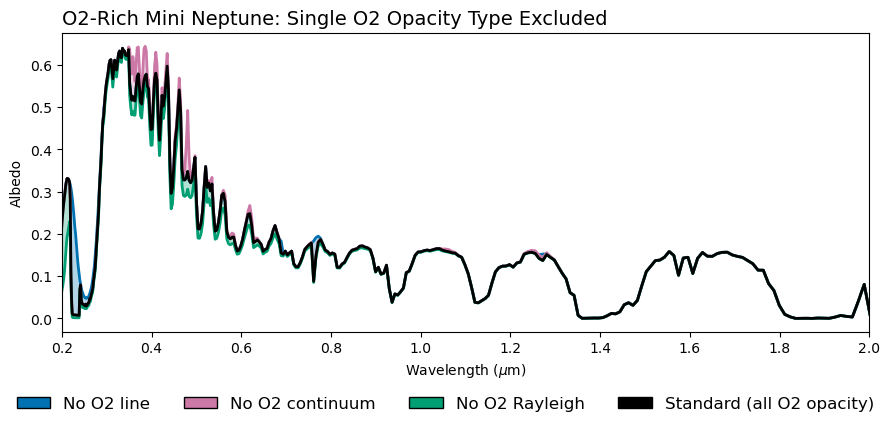

In [4]:
# Single-type exclusion: line, continuum, rayleigh
# Index: 0=noLine, 1=noCont, 2=noRay, 3=standard (reference)
_colors_single = ["#0072B2", "#CC79A7", "#009E73", "#000000"]

wno_single = [c2_noLine['wno'], c2_noCont['wno'], c2_noRay['wno'], c2_standard['wno']]
alb_single = [c2_noLine['alb'], c2_noCont['alb'], c2_noRay['alb'], c2_standard['alb']]
labels_single = ['No O2 line', 'No O2 continuum', 'No O2 Rayleigh', 'Standard (all O2 opacity)']

fig, ax = plt.subplots(1, 1, figsize=(9, 4))

plot_reflected_spectrum_final(
    wno=wno_single,
    alb=alb_single,
    inputs=[None]*4,
    legend_label=labels_single,
    ax1=ax,
    fill_indices=[0, 1, 2],
    fill_between_ref=True,
    fill_ref_index=3,
    colors=_colors_single,
    show_legend=False,
    show_xlabel=True,
)

ax.set_title("O2-Rich Mini Neptune: Single O2 Opacity Type Excluded", loc='left', fontsize=14)

handles = [Patch(facecolor=_colors_single[i], edgecolor='black', label=labels_single[i]) for i in range(4)]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.08), fontsize=12)

plt.tight_layout()
plt.show()

## Figure: Two Opacity Types Excluded

Each colored band shows how the spectrum changes relative to the standard (black) when two O2 opacity types are removed simultaneously.

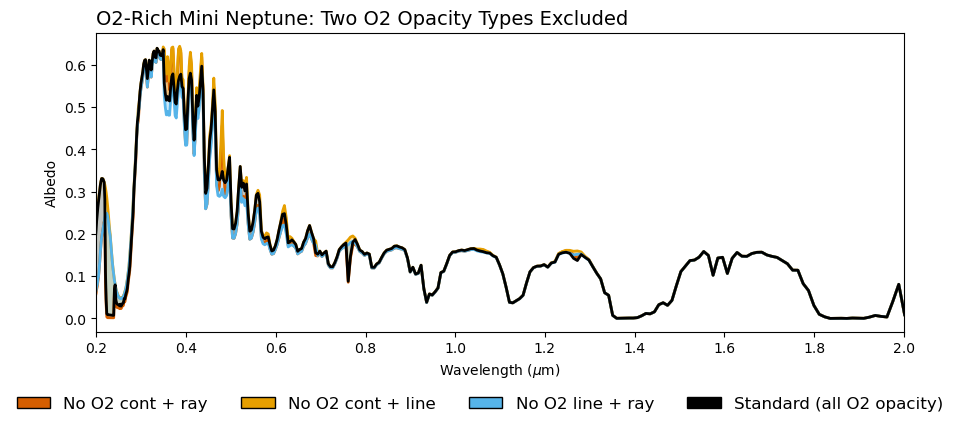

In [5]:
# Two-type exclusion: continuum+rayleigh, continuum+line, line+rayleigh
# Index: 0=noContRay, 1=noContLine, 2=noLineRay, 3=standard (reference)
_colors_double = ["#D55E00", "#E69F00", "#56B4E9", "#000000"]

wno_double = [c2_noContRay['wno'], c2_noContLine['wno'], c2_noLineRay['wno'], c2_standard['wno']]
alb_double = [c2_noContRay['alb'], c2_noContLine['alb'], c2_noLineRay['alb'], c2_standard['alb']]
labels_double = ['No O2 cont + ray', 'No O2 cont + line', 'No O2 line + ray', 'Standard (all O2 opacity)']

fig, ax = plt.subplots(1, 1, figsize=(9, 4))

plot_reflected_spectrum_final(
    wno=wno_double,
    alb=alb_double,
    inputs=[None]*4,
    legend_label=labels_double,
    ax1=ax,
    fill_indices=[0, 1, 2],
    fill_between_ref=True,
    fill_ref_index=3,
    colors=_colors_double,
    show_legend=False,
    show_xlabel=True,
)

ax.set_title("O2-Rich Mini Neptune: Two O2 Opacity Types Excluded", loc='left', fontsize=14)

handles = [Patch(facecolor=_colors_double[i], edgecolor='black', label=labels_double[i]) for i in range(4)]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.08), fontsize=12)

plt.tight_layout()
plt.show()

## Figure: All 6 Cases Together (Figure 4 Style)

Both panels use the same Figure 4 style (`fill_between_ref=True`): fills show difference from the standard.

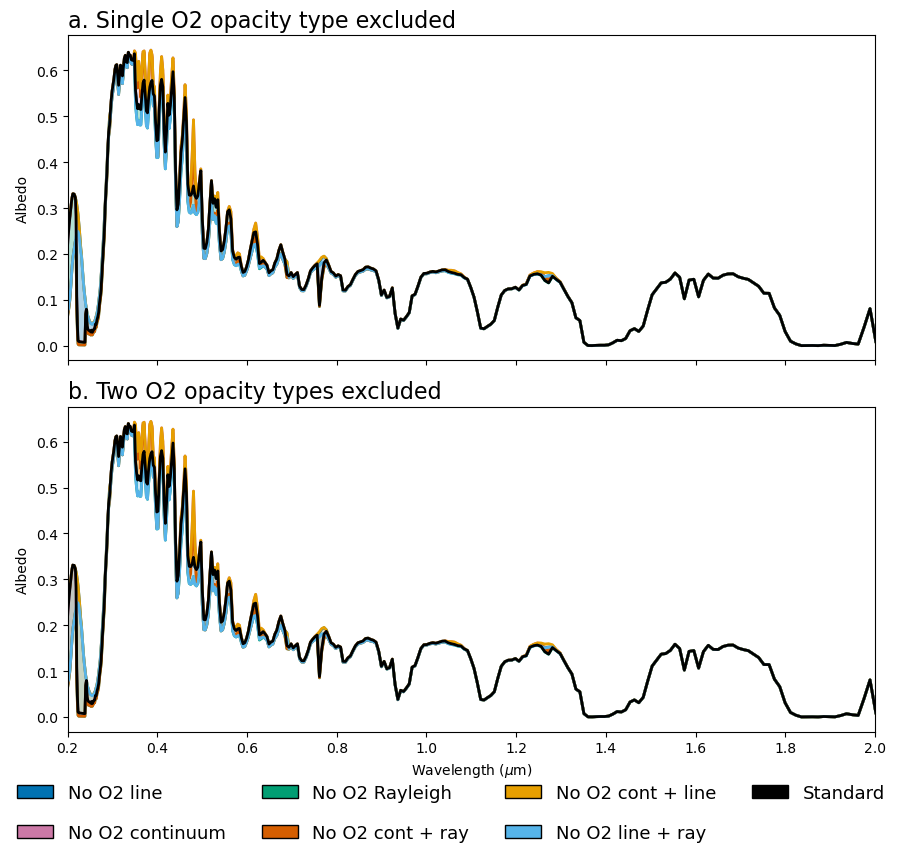

In [6]:
# All 6 selective exclusion cases + reference
# Order: noLine, noCont, noRay, noContRay, noContLine, noLineRay, standard
_colors_all = ["#0072B2", "#CC79A7", "#009E73", "#D55E00", "#E69F00", "#56B4E9", "#000000"]

wno_all = [
    c2_noLine['wno'], c2_noCont['wno'], c2_noRay['wno'],
    c2_noContRay['wno'], c2_noContLine['wno'], c2_noLineRay['wno'],
    c2_standard['wno'],
]
alb_all = [
    c2_noLine['alb'], c2_noCont['alb'], c2_noRay['alb'],
    c2_noContRay['alb'], c2_noContLine['alb'], c2_noLineRay['alb'],
    c2_standard['alb'],
]
labels_all = [
    'No O2 line',
    'No O2 continuum',
    'No O2 Rayleigh',
    'No O2 cont + ray',
    'No O2 cont + line',
    'No O2 line + ray',
    'Standard',
]

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Top panel: single-type exclusions (indices 0,1,2) vs reference (index 6)
plot_reflected_spectrum_final(
    wno=wno_all, alb=alb_all, inputs=[None]*7, legend_label=labels_all,
    ax1=axes[0],
    fill_indices=[0, 1, 2],
    fill_between_ref=True, fill_ref_index=6,
    colors=_colors_all, show_legend=False, show_xlabel=False,
)

# Bottom panel: two-type exclusions (indices 3,4,5) vs reference (index 6)
plot_reflected_spectrum_final(
    wno=wno_all, alb=alb_all, inputs=[None]*7, legend_label=labels_all,
    ax1=axes[1],
    fill_indices=[3, 4, 5],
    fill_between_ref=True, fill_ref_index=6,
    colors=_colors_all, show_legend=False, show_xlabel=True,
)

axes[0].set_title("a. Single O2 opacity type excluded", loc='left', fontsize=16)
axes[1].set_title("b. Two O2 opacity types excluded", loc='left', fontsize=16)

handles = [Patch(facecolor=_colors_all[i], edgecolor='black', label=labels_all[i]) for i in range(7)]
fig.legend(
    handles=handles, loc='lower center', ncol=4, frameon=False,
    bbox_to_anchor=(0.5, -0.08), fontsize=13, labelspacing=1.2
)

plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.savefig('FinalPaperFigs/O2Rich_MiniNep_SelectiveO2Opacity.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Figure: Gas Absorption Context (Figure 4 Style)

Reproduces the gas contribution breakdown for the O2-rich mini-neptune, showing where O2 fits among all molecules. This gives context for the selective O2 opacity plots above.

In [7]:
# Load remaining gas exclusion cases for context comparison
c2_noO3  = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noO3_cld0.5.pkl')
c2_noCO2 = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noCO2_cld0.5.pkl')
c2_noH2O = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noH2O_cld0.5.pkl')

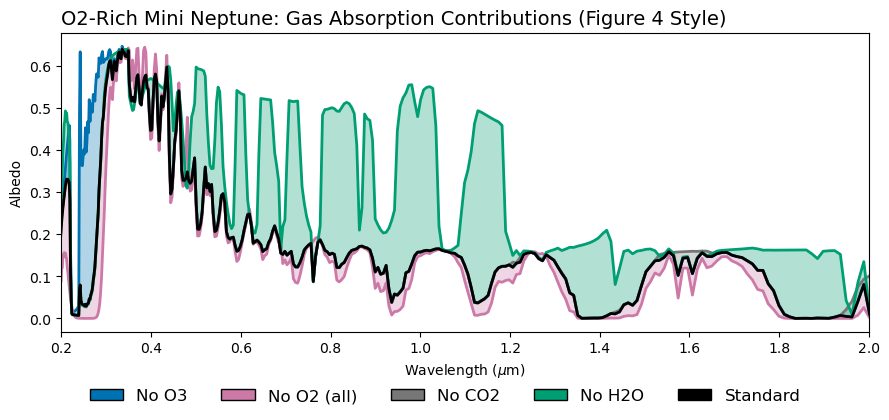

In [8]:
# Gas absorption context: Figure 4 style (matches W28_PaperResults_Figures.ipynb cell 47)
# Order: noO3, noO2, noCO2, noH2O, standard — fills show each molecule's contribution
_colors_gas = ["#0072B2", "#CC79A7", "#777777", "#009E73", "#000000"]

wno_gas = [c2_noO3['wno'], c2_noO2['wno'], c2_noCO2['wno'], c2_noH2O['wno'], c2_standard['wno']]
alb_gas = [c2_noO3['alb'], c2_noO2['alb'], c2_noCO2['alb'], c2_noH2O['alb'], c2_standard['alb']]
labels_gas = ['No O3', 'No O2 (all)', 'No CO2', 'No H2O', 'Standard']

fig, ax = plt.subplots(1, 1, figsize=(9, 4))

plot_reflected_spectrum_final(
    wno=wno_gas,
    alb=alb_gas,
    inputs=[None]*5,
    legend_label=labels_gas,
    ax1=ax,
    fill_indices=[0, 1, 2, 3],
    fill_between_ref=True,
    fill_ref_index=4,
    colors=_colors_gas,
    show_legend=False,
    show_xlabel=True,
)

ax.set_title("O2-Rich Mini Neptune: Gas Absorption Contributions (Figure 4 Style)", loc='left', fontsize=14)

handles = [Patch(facecolor=_colors_gas[i], edgecolor='black', label=labels_gas[i]) for i in range(5)]
fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False,
           bbox_to_anchor=(0.5, -0.06), fontsize=12)

plt.tight_layout()
plt.show()

## Figure: Combined 3-Panel — Gas Context + O2 Opacity Breakdown

All three comparisons in one figure: (a) gas absorption contributions by molecule, (b) single O2 opacity type excluded, (c) two O2 opacity types excluded. Fills show the difference from the standard spectrum in each case.

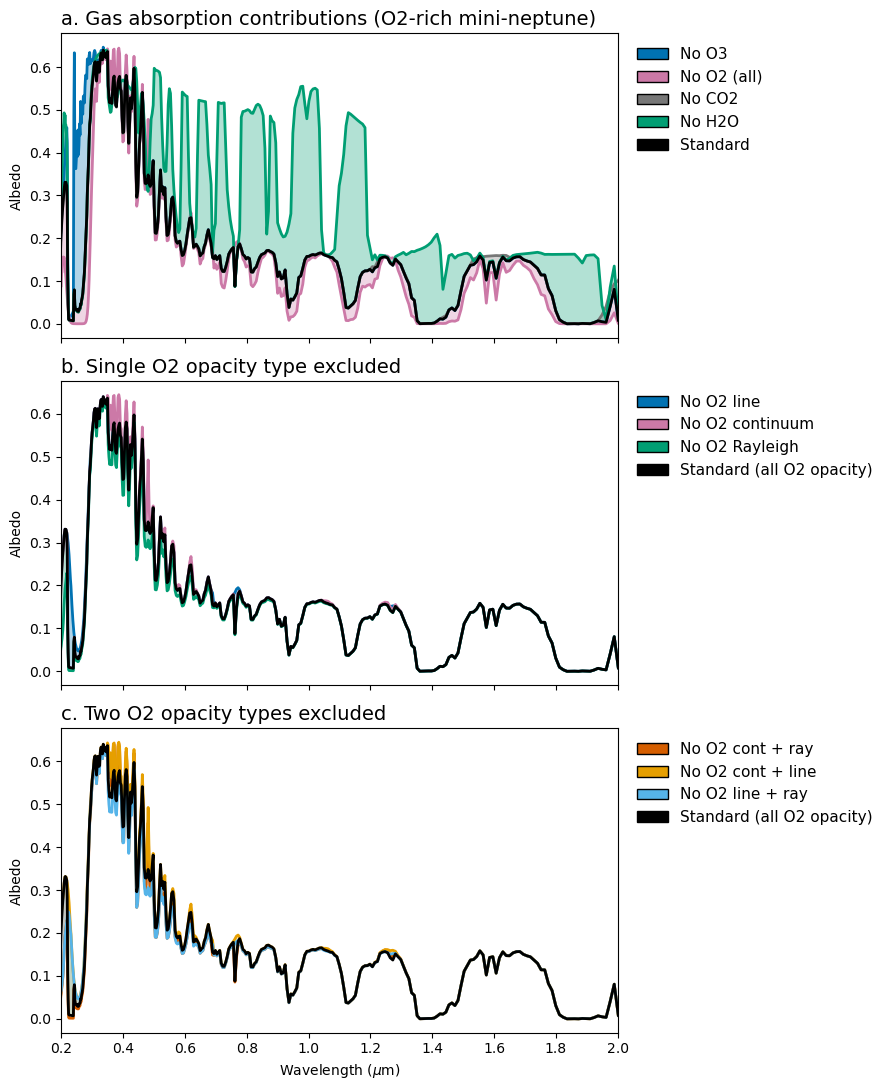

In [9]:
# Combined 3-panel: gas context (top), single O2 opacity (middle), two O2 opacities (bottom)
# All panels share x-axis; fills show difference from standard
fig, axes = plt.subplots(3, 1, figsize=(9, 11), sharex=True)

# --- (a) Gas absorption context ---
_colors_gas = ["#0072B2", "#CC79A7", "#777777", "#009E73", "#000000"]
wno_gas = [c2_noO3['wno'], c2_noO2['wno'], c2_noCO2['wno'], c2_noH2O['wno'], c2_standard['wno']]
alb_gas = [c2_noO3['alb'], c2_noO2['alb'], c2_noCO2['alb'], c2_noH2O['alb'], c2_standard['alb']]
labels_gas = ['No O3', 'No O2 (all)', 'No CO2', 'No H2O', 'Standard']

plot_reflected_spectrum_final(
    wno=wno_gas, alb=alb_gas, inputs=[None]*5, legend_label=labels_gas,
    ax1=axes[0],
    fill_indices=[0, 1, 2, 3],
    fill_between_ref=True, fill_ref_index=4,
    colors=_colors_gas, show_legend=False, show_xlabel=False,
)

# --- (b) Single O2 opacity type excluded ---
_colors_single = ["#0072B2", "#CC79A7", "#009E73", "#000000"]
wno_single = [c2_noLine['wno'], c2_noCont['wno'], c2_noRay['wno'], c2_standard['wno']]
alb_single = [c2_noLine['alb'], c2_noCont['alb'], c2_noRay['alb'], c2_standard['alb']]
labels_single = ['No O2 line', 'No O2 continuum', 'No O2 Rayleigh', 'Standard (all O2 opacity)']

plot_reflected_spectrum_final(
    wno=wno_single, alb=alb_single, inputs=[None]*4, legend_label=labels_single,
    ax1=axes[1],
    fill_indices=[0, 1, 2],
    fill_between_ref=True, fill_ref_index=3,
    colors=_colors_single, show_legend=False, show_xlabel=False,
)

# --- (c) Two O2 opacity types excluded ---
_colors_double = ["#D55E00", "#E69F00", "#56B4E9", "#000000"]
wno_double = [c2_noContRay['wno'], c2_noContLine['wno'], c2_noLineRay['wno'], c2_standard['wno']]
alb_double = [c2_noContRay['alb'], c2_noContLine['alb'], c2_noLineRay['alb'], c2_standard['alb']]
labels_double = ['No O2 cont + ray', 'No O2 cont + line', 'No O2 line + ray', 'Standard (all O2 opacity)']

plot_reflected_spectrum_final(
    wno=wno_double, alb=alb_double, inputs=[None]*4, legend_label=labels_double,
    ax1=axes[2],
    fill_indices=[0, 1, 2],
    fill_between_ref=True, fill_ref_index=3,
    colors=_colors_double, show_legend=False, show_xlabel=True,
)

axes[0].set_title("a. Gas absorption contributions (O2-rich mini-neptune)", loc='left', fontsize=14)
axes[1].set_title("b. Single O2 opacity type excluded", loc='left', fontsize=14)
axes[2].set_title("c. Two O2 opacity types excluded", loc='left', fontsize=14)

# Per-panel legends placed outside right edge
leg_a = [Patch(facecolor=_colors_gas[i],    edgecolor='black', label=labels_gas[i])    for i in range(5)]
leg_b = [Patch(facecolor=_colors_single[i], edgecolor='black', label=labels_single[i]) for i in range(4)]
leg_c = [Patch(facecolor=_colors_double[i], edgecolor='black', label=labels_double[i]) for i in range(4)]

axes[0].legend(handles=leg_a, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=11, frameon=False)
axes[1].legend(handles=leg_b, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=11, frameon=False)
axes[2].legend(handles=leg_c, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=11, frameon=False)

plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.savefig('FinalPaperFigs/O2Rich_MiniNep_GasContext_O2Breakdown_3panel.pdf', dpi=300, bbox_inches='tight')
plt.show()